In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, OrdinalEncoder, OneHotEncoder

BLUE  = '#4CBBF0'
RED   = '#F06A6A'
GREEN = '#6BCB77'

# 1. CHARGEMENT DU DATASET
On charge le fichier brut en remplaçant directement les "?" par NaN.

In [5]:
df = pd.read_csv("diabetic_data.csv", na_values="?")
print(f"  Dimensions initiales : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"  Valeurs manquantes   : {df.isnull().sum().sum():,}")

  Dimensions initiales : 101,766 lignes × 50 colonnes
  Valeurs manquantes   : 374,017


In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# 2. SUPPRESSION DES COLONNES INUTILES

Critères de suppression :
  - *Identifiants uniques*  : aucune valeur prédictive
  - *Taux de NaN > 40%*      : trop peu d'information exploitable
  - *Colonnes quasi-constantes* : variance nulle, inutiles au modèle

Colonnes supprimées :

  • **encounter_id**     : identifiant de visite, unique par ligne

  • **weight**            : 97 % de valeurs manquantes

  • **medical_specialty** : ~50 % de valeurs manquantes

  • **examide**           : une seule valeur ("No") dans tout le dataset

  • citoglipton       : même problème (colonne constante)

  • **payer_code**        : ~40 % de NaN + non pertinent cliniquement


In [6]:
colonnes_a_supprimer = [
    'encounter_id',
    'weight',
    'medical_specialty',
    'examide',
    'citoglipton',
    'payer_code',
]

df = df.drop(columns=colonnes_a_supprimer)

print(f"  Colonnes supprimées  : {colonnes_a_supprimer}")
print(f"  Dimensions restantes : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

  Colonnes supprimées  : ['encounter_id', 'weight', 'medical_specialty', 'examide', 'citoglipton', 'payer_code']
  Dimensions restantes : 101,766 lignes × 44 colonnes


# 3. NETTOYAGE DES VALEURS ABERRANTES
+ La colonne '**gender**' contient une valeur invalide : "Unknown/Invalid".
Elle représente seulement 3 lignes (~0.003 % du dataset).
On les supprime plutôt que d'imputer, car l'information est non récupérable.


+ On conserve les visites multiples d'un même patient (pas de déduplication
par patient_nbr) : l'**historique** des hospitalisations est une information
médicalement pertinente pour la prédiction de réadmission.

In [7]:
print(f"  Valeurs de 'gender' avant nettoyage :\n{df['gender'].value_counts().to_string()}")

df = df[df['gender'] != 'Unknown/Invalid']

print(f"\n  Lignes après suppression : {len(df):,}")
print(f"  Patients uniques conservés : {df['patient_nbr'].nunique():,}")


  Valeurs de 'gender' avant nettoyage :
gender
Female             54708
Male               47055
Unknown/Invalid        3

  Lignes après suppression : 101,763
  Patients uniques conservés : 71,515


# 4. REGROUPEMENT DES CODES DIAGNOSTIQUES ICD-9

Les codes diagnostiques utilisés dans ce projet sont basés sur la classification médicale internationale ICD-9.
Les intervalles numériques utilisés pour le regroupement correspondent aux catégories officielles définies par cette classification.

Cependant, afin de réduire la complexité et la cardinalité des variables :
+ Trop de catégories →  overfitting
+ Trop de détails →  bruit
+ Trop de valeurs uniques →  OneHot énorme

ces codes ont été regroupés en un nombre limité de grandes catégories médicales.
Ce regroupement est une simplification couramment utilisée en data science, permettant d'améliorer la performance et la généralisation des modèles de machine learning.

In [8]:
def regrouper_diagnostic(code):
    """Convertit un code ICD-9 en grande catégorie médicale."""
    if pd.isnull(code):
        return 'Autre'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Autre'
    try:
        code_num = float(code)
    except ValueError:
        return 'Autre'

    if 390 <= code_num <= 459 or code_num == 785:   return 'Circulatoire'
    elif 460 <= code_num <= 519 or code_num == 786: return 'Respiratoire'
    elif 520 <= code_num <= 579 or code_num == 787: return 'Digestif'
    elif code_num == 250:                           return 'Diabète'
    elif 800 <= code_num <= 999:                    return 'Blessure'
    elif 710 <= code_num <= 739:                    return 'Musculo-squelettique'
    elif 580 <= code_num <= 629 or code_num == 788: return 'Génito-urinaire'
    elif 140 <= code_num <= 239:                    return 'Néoplasme'
    else:                                           return 'Autre'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(regrouper_diagnostic)
print("  Catégories de diag_1 :")
print(df['diag_1'].value_counts().to_string())


  Catégories de diag_1 :
diag_1
Circulatoire            30436
Autre                   26715
Respiratoire            14423
Digestif                 9475
Blessure                 6972
Génito-urinaire          5117
Musculo-squelettique     4957
Néoplasme                3433
Diabète                   235


In [9]:
print("  Catégories de diag_2 :")
print(df['diag_2'].value_counts().to_string())

  Catégories de diag_2 :
diag_2
Autre                   33634
Circulatoire            31880
Respiratoire            10895
Génito-urinaire          8376
Diabète                  6071
Digestif                 4170
Néoplasme                2547
Blessure                 2426
Musculo-squelettique     1764


# 5. BINARISATION DES VARIABLES CIBLES

Deux cibles binaires pour la classification multilabel :

  + readmitted_bin :
    + 1 → patient réadmis en moins de 30 jours ("<30")
    + 0 → sinon ("NO" ou ">30")
    Déséquilibre marqué : ~11 % de positifs

  + change_bin :
    + 1 → changement de traitement pendant l'hospitalisation ("Ch")
    + 0 → pas de changement ("No")
    Distribution plus équilibrée : ~46 % de positifs

In [10]:
df[['readmitted', 'change']].head()

,readmitted,change
0,NO,No
1,>30,Ch
2,NO,No
3,NO,Ch
4,NO,Ch


In [11]:
df['readmitted_bin'] = (df['readmitted'] == '<30').astype(int)
df['change_bin']     = (df['change']     == 'Ch' ).astype(int)
df = df.drop(columns=['readmitted', 'change'])
print(f"  readmitted_bin → {df['readmitted_bin'].value_counts().to_dict()}")
print(f"  change_bin     → {df['change_bin'].value_counts().to_dict()}")
print(f"  % positifs readmitted_bin : {df['readmitted_bin'].mean()*100:.1f}%")
print(f"  % positifs change_bin     : {df['change_bin'].mean()*100:.1f}%")

  readmitted_bin → {0: 90406, 1: 11357}
  change_bin     → {0: 54754, 1: 47009}
  % positifs readmitted_bin : 11.2%
  % positifs change_bin     : 46.2%


In [12]:
df[['readmitted_bin', 'change_bin']].head()

,readmitted_bin,change_bin
0,0,0
1,0,1
2,0,0
3,0,1
4,0,1


# 6.IMPUTATION DES VALEURS MANQUANTES

Stratégie différenciée selon le type de variable :

  + Variables numériques  : médiane

    *Avantage* : robuste aux outliers (détectés en EDA)
    
    **Les outliers faussent la moyenne mais pas la médiane**

  + Variable 'race'       : catégorie "Unknown"

    *Justification* : ~2 % de NaN ; l'ethnie est une info médicale
    sensible. Créer une catégorie "Unknown" préserve l'information
    de données manquantes plutôt que de biaiser vers la majorité.

  + Colonnes diag_*       : catégorie "Autre"

    *Justification* : un NaN signifie "diagnostic non renseigné",
    ce qui correspond sémantiquement à "Autre".

  + Autres catégorielles  : mode (valeur la plus fréquente)

    *Justification* : peu de NaN, variable stable.

In [13]:
# Colonnes numériques (hors cibles)
num_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns
            if c not in ['readmitted_bin', 'change_bin']]

# Colonnes catégorielles (hors cibles)
cat_cols = [c for c in df.select_dtypes(include=['object']).columns
            if c not in ['readmitted_bin', 'change_bin']]

# Numériques : médiane
for col in num_cols:
    n_nan = df[col].isnull().sum()
    if n_nan > 0:
        median = df[col].median()
        df[col] = df[col].fillna(median)
        print(f"  [NUM] {col:<30} : {n_nan} NaN → médiane ({median})")

# Catégorielles : stratégie intelligente
unknown_cols = ['race']
autre_cols   = ['diag_1', 'diag_2', 'diag_3']

for col in cat_cols:
    n_nan = df[col].isnull().sum()
    if n_nan > 0:
        if col in unknown_cols:
            df[col] = df[col].fillna("Unknown")
            print(f"  [CAT] {col:<30} : {n_nan} NaN → 'Unknown'")
        elif col in autre_cols:
            df[col] = df[col].fillna("Autre")
            print(f"  [CAT] {col:<30} : {n_nan} NaN → 'Autre'")
        else:
            mode = df[col].mode().values[0]
            df[col] = df[col].fillna(mode)
            print(f"  [CAT] {col:<30} : {n_nan} NaN → mode ('{mode}')")

print(f"\n   Valeurs manquantes restantes : {df.isnull().sum().sum()}")

  [CAT] race                           : 2271 NaN → 'Unknown'
  [CAT] max_glu_serum                  : 96417 NaN → mode ('Norm')
  [CAT] A1Cresult                      : 84745 NaN → mode ('>8')

   Valeurs manquantes restantes : 0


#7. ENCODAGE DES VARIABLES CATÉGORIELLES

###  Encodage binaire — `gender`

La variable **`gender`** contient uniquement deux modalités : **Male** et **Female**.
Dans ce cas, un encodage binaire simple est utilisé :

* **Female → 0**
* **Male → 1**

Ce choix est justifié par le fait qu’il n’y a que deux catégories. L’utilisation d’un encodage plus complexe comme le One-Hot Encoding serait inutile et introduirait des colonnes supplémentaires sans gain d’information.

Cet encodage permet de garder une représentation simple, efficace et directement exploitable par les modèles de machine learning.


In [14]:
df_encoded = df.copy()

# Encodage binaire : gender
df_encoded['gender'] = (df_encoded['gender'] == 'Male').astype(int)
print("  [BINAIRE]  gender → 0=Female, 1=Male")


  [BINAIRE]  gender → 0=Female, 1=Male


###  Encodage ordinal — `A1Cresult`, `max_glu_serum`, `age` et médicaments

Certaines variables possèdent un **ordre naturel** qu’il est essentiel de préserver pour que le modèle comprenne correctement les relations entre les valeurs. Pour cela, nous utilisons **OrdinalEncoder**.

---

###  Principe de l’OrdinalEncoder

L’OrdinalEncoder transforme des catégories en valeurs numériques **en respectant un ordre défini**.

Exemple :

* Low → 0
* Medium → 1
* High → 2

Ainsi, le modèle comprend que **2 > 1 > 0**, ce qui donne du sens aux données.

---

###  Application aux variables médicales

#### 1. `A1Cresult`

Ordre médical :

```
None < Norm < >7 < >8
```

Encodage :

* None → 0
* Norm → 1
* > 7 → 2
* > 8 → 3

 Le modèle comprend donc que :

* `>8` est plus grave que `>7`
* `Norm` est meilleur que `>7`

Sans cet encodage, le modèle ne pourrait pas interpréter cette hiérarchie.

---

#### 2. `age`

La variable **age** est représentée sous forme de tranches :

```
[0-10), [10-20), ..., [90-100)
```

Un ordre explicite est défini :

```python
age_order = ['[0-10)', '[10-20)', ..., '[90-100)']
```

Puis transformé en valeurs numériques :

* [0-10) → 0
* [10-20) → 1
* [20-30) → 2
* ...
* [90-100) → 9

 Cela permet au modèle de comprendre que l’âge est une variable progressive, ce qui est crucial en contexte médical.

---

#### 3. Médicaments

Chaque médicament possède les modalités suivantes :

```
No, Steady, Down, Up
```

Encodage appliqué :

* No → 0 (non prescrit)
* Steady → 1 (dose stable)
* Down → 2 (dose diminuée)
* Up → 3 (dose augmentée)

 Ce choix permet de capturer une **notion d’intensité du traitement**, utile pour la prédiction clinique.

---

###  Remarque importante

L’OrdinalEncoder impose un ordre. Il doit donc être utilisé uniquement lorsque cet ordre a un sens réel (médical ou logique). Sinon, il peut introduire un biais.


In [15]:
# Encodage ordinal : A1Cresult, max_glu_serum
a1c_order = ['None', 'Norm', '>7', '>8']
glu_order  = ['None', 'Norm', '>200', '>300']

ord_enc_medical = OrdinalEncoder(categories=[a1c_order, glu_order])
df_encoded[['A1Cresult', 'max_glu_serum']] = ord_enc_medical.fit_transform(
    df_encoded[['A1Cresult', 'max_glu_serum']]
)
print("  [ORDINAL]  A1Cresult    → None=0, Norm=1, >7=2, >8=3")
print("  [ORDINAL]  max_glu_serum → None=0, Norm=1, >200=2, >300=3")


  [ORDINAL]  A1Cresult    → None=0, Norm=1, >7=2, >8=3
  [ORDINAL]  max_glu_serum → None=0, Norm=1, >200=2, >300=3


In [16]:
# Encodage ordinal : age
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
ord_enc_age = OrdinalEncoder(categories=[age_order])
df_encoded['age'] = ord_enc_age.fit_transform(df_encoded[['age']])
print("  [ORDINAL]  age → [0-10)=0 … [90-100)=9")


  [ORDINAL]  age → [0-10)=0 … [90-100)=9


In [17]:
# Encodage ordinal : médicaments (23 colonnes)
colonnes_medicaments = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone'
]
# Filtrer les colonnes présentes dans le df
colonnes_medicaments = [c for c in colonnes_medicaments if c in df_encoded.columns]
med_order = [['No', 'Steady', 'Down', 'Up']] * len(colonnes_medicaments)

ord_enc_med = OrdinalEncoder(categories=med_order, handle_unknown='use_encoded_value', unknown_value=-1)
df_encoded[colonnes_medicaments] = ord_enc_med.fit_transform(df_encoded[colonnes_medicaments])
print(f"  [ORDINAL]  {len(colonnes_medicaments)} colonnes médicaments → No=0, Steady=1, Down=2, Up=3")


  [ORDINAL]  21 colonnes médicaments → No=0, Steady=1, Down=2, Up=3


###  One-Hot Encoding — `race`, `diag_1`, `diag_2`, `diag_3`

Certaines variables sont **nominales**, c’est-à-dire qu’elles ne possèdent **aucun ordre naturel**.

Exemples :

* `race` : Caucasian, AfricanAmerican, Asian…
* `diag_1/2/3` : Circulatoire, Respiratoire, Digestif…

---

###  Pourquoi ne pas utiliser OrdinalEncoder ?

Si on encode par exemple :

* Circulatoire → 0
* Respiratoire → 1
* Digestif → 2

Le modèle va interpréter :

```
Digestif > Respiratoire > Circulatoire
```

 Ce qui est **biologiquement faux**.

---

###  Solution : OneHotEncoder

Le OneHotEncoder transforme chaque catégorie en une colonne binaire :

Exemple :

* Circulatoire → [1,0,0]
* Respiratoire → [0,1,0]
* Digestif → [0,0,1]

 Cela permet :

* d’éviter tout biais d’ordre
* de représenter fidèlement les catégories

---

###  Pourquoi `drop='first'` ?

Le paramètre `drop='first'` est utilisé pour éviter le problème de **multicolinéarité** (Dummy Variable Trap).

Exemple :
Si on a :

* Race_A
* Race_B
* Race_C

 Une colonne est redondante (elle peut être déduite des autres).

---

###  Avantages

* Réduction du nombre de variables
* Modèle plus stable
* Moins de redondance


###  Gestion des valeurs inconnues

#### 1. `handle_unknown='ignore'` (OneHotEncoder)

Lors de la phase de test ou en production, il est possible de rencontrer **de nouvelles catégories jamais vues pendant l'entraînement**.

 Sans ce paramètre :

* le modèle génère une erreur

 Avec `handle_unknown='ignore'` :

* la catégorie est ignorée proprement
* le pipeline reste stable et robuste

---

#### 2. `unknown_value = -1` (OrdinalEncoder pour médicaments)

Pour les variables encodées avec OrdinalEncoder (notamment les médicaments), une valeur inconnue est remplacée par **-1**.

 Cela permet :

* d’éviter les erreurs
* de gérer des données nouvelles
* de garantir la robustesse du modèle

---

###  Conclusion

Ces mécanismes assurent que le modèle :

* ne plante pas face à des données inédites
* reste utilisable en conditions réelles
* est robuste et généralisable


In [18]:
#One-Hot Encoding : variables nominales
cols_ohe = ['race', 'diag_1', 'diag_2', 'diag_3']
cols_ohe = [c for c in cols_ohe if c in df_encoded.columns]

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_array  = ohe.fit_transform(df_encoded[cols_ohe])
ohe_cols   = ohe.get_feature_names_out(cols_ohe)
df_ohe     = pd.DataFrame(ohe_array, columns=ohe_cols, index=df_encoded.index)

df_encoded = df_encoded.drop(columns=cols_ohe)
df_encoded = pd.concat([df_encoded, df_ohe], axis=1)

print(f"  [OHE]      {cols_ohe} → {len(ohe_cols)} nouvelles colonnes")
print(f"\n  Dimensions après encodage : {df_encoded.shape[0]:,} lignes × {df_encoded.shape[1]} colonnes")


  [OHE]      ['race', 'diag_1', 'diag_2', 'diag_3'] → 29 nouvelles colonnes

  Dimensions après encodage : 101,763 lignes × 69 colonnes


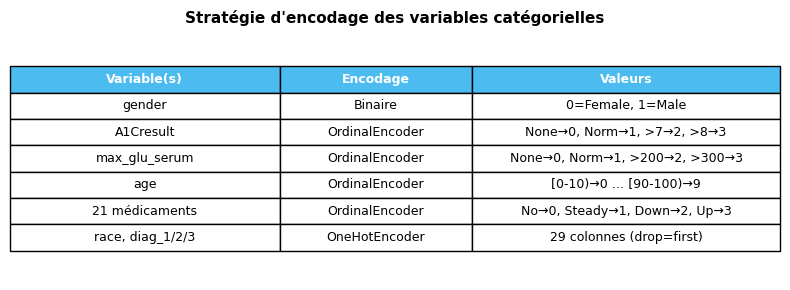

In [19]:
# Visualisation
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table_data = [
    ['Variable(s)',              'Encodage',       'Valeurs'],
    ['gender',                   'Binaire',        '0=Female, 1=Male'],
    ['A1Cresult',                'OrdinalEncoder', 'None→0, Norm→1, >7→2, >8→3'],
    ['max_glu_serum',            'OrdinalEncoder', 'None→0, Norm→1, >200→2, >300→3'],
    ['age',                      'OrdinalEncoder', '[0-10)→0 … [90-100)→9'],
    [f'{len(colonnes_medicaments)} médicaments', 'OrdinalEncoder', 'No→0, Steady→1, Down→2, Up→3'],
    ['race, diag_1/2/3',         'OneHotEncoder',  f'{len(ohe_cols)} colonnes (drop=first)'],
]
t = ax.table(cellText=table_data[1:], colLabels=table_data[0],
             cellLoc='center', loc='center',
             colWidths=[0.35, 0.25, 0.40])
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.5)
for j in range(3):
    t[0, j].set_facecolor('#4CBBF0')
    t[0, j].set_text_props(color='white', fontweight='bold')
plt.title("Stratégie d'encodage des variables catégorielles",
          fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

# Conclusions generales :
L’OrdinalEncoder a été utilisé pour transformer les variables catégorielles ordinales en valeurs numériques tout en respectant leur ordre naturel. Contrairement à un encodage classique, cette méthode permet au modèle de capturer les relations de hiérarchie entre les catégories, ce qui est particulièrement important dans un contexte médical où certaines valeurs représentent des niveaux de gravité ou d’intensité.


Le choix des méthodes d’encodage a été réalisé en fonction de la nature sémantique de chaque variable. Les variables binaires ont été encodées directement en 0/1 pour plus de simplicité. Les variables ordinales, telles que les résultats médicaux et les tranches d’âge, ont été transformées à l’aide d’un OrdinalEncoder afin de préserver leur ordre naturel, essentiel à l’interprétation clinique. Les variables nominales, ne présentant aucun ordre logique, ont été encodées via OneHotEncoder afin d’éviter l’introduction de biais artificiels. Enfin, les variables liées aux médicaments ont été traitées comme ordinales, car elles représentent une progression dans l’intensité du traitement. Cette approche permet d’assurer une représentation fidèle des données et d’améliorer la performance et la robustesse des modèles.


#  8. Normalisation des variables numériques — RobustScaler

Dans cette étape, nous appliquons une **normalisation des variables numériques** afin d’améliorer les performances du modèle.

Les variables du dataset n’ont pas la même échelle : certaines prennent de petites valeurs (comme `time_in_hospital`), tandis que d’autres peuvent avoir des valeurs beaucoup plus élevées (comme `num_lab_procedures` ou `number_inpatient`). Sans normalisation, ces différences peuvent biaiser le modèle, notamment pour les algorithmes sensibles à l’échelle des données.

---

###  Problème identifié lors de l’EDA

L’analyse exploratoire a révélé la présence de **valeurs extrêmes (outliers)** dans plusieurs variables, notamment :

* `number_outpatient`
* `number_emergency`
* `number_inpatient`

Ces valeurs peuvent fortement perturber certaines méthodes de normalisation classiques.

---

###  Choix de la méthode : RobustScaler

Nous avons choisi d’utiliser **RobustScaler**, car il est spécialement conçu pour être **robuste aux outliers**.

Contrairement aux autres méthodes :

* **StandardScaler** utilise la moyenne et l’écart-type → sensible aux valeurs extrêmes
* **MinMaxScaler** ramène les données entre 0 et 1 → très sensible aux outliers
* **RobustScaler** utilise la médiane et l’IQR (intervalle interquartile) → robuste

Le principe est de centrer les données autour de la médiane et de les réduire selon l’IQR.

---

###  Colonnes concernées

Seules les **variables numériques continues** sont normalisées :

* `time_in_hospital`
* `num_lab_procedures`
* `num_procedures`
* `num_medications`
* `number_outpatient`
* `number_emergency`
* `number_inpatient`
* `number_diagnoses`

Les variables catégorielles encodées ainsi que les variables cibles ne sont pas concernées.

---

###  Visualisation

Des histogrammes avant/après normalisation sont affichés pour illustrer l’effet du scaling.
On observe que :

* les distributions deviennent plus stables
* l’impact des valeurs extrêmes est réduit

---



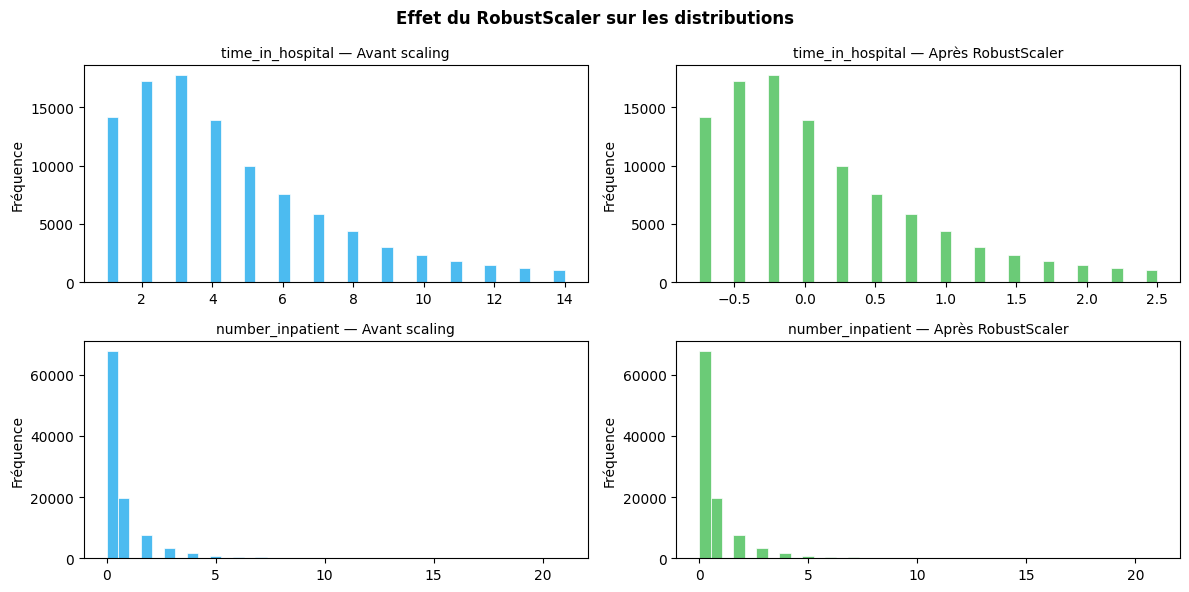

  Colonnes scalées (8) : ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
  Statistiques après scaling (time_in_hospital) :
    Médiane : 0.0000  (attendu ≈ 0)
    IQR     : Q1=-0.500, Q3=0.500


In [20]:
target_cols = ['readmitted_bin', 'change_bin']

cols_to_scale = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]
cols_to_scale = [c for c in cols_to_scale if c in df_encoded.columns]

# Visualisation avant/après scaling sur 2 colonnes exemple
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
exemples = ['time_in_hospital', 'number_inpatient']

scaler = RobustScaler()
df_scaled = df_encoded.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

for i, col in enumerate(exemples):
    # Avant
    axes[i, 0].hist(df_encoded[col], bins=40, color=BLUE, edgecolor='white', linewidth=0.5)
    axes[i, 0].set_title(f'{col} — Avant scaling', fontsize=10)
    axes[i, 0].set_ylabel('Fréquence')
    # Après
    axes[i, 1].hist(df_scaled[col], bins=40, color=GREEN, edgecolor='white', linewidth=0.5)
    axes[i, 1].set_title(f'{col} — Après RobustScaler', fontsize=10)
    axes[i, 1].set_ylabel('Fréquence')

plt.suptitle('Effet du RobustScaler sur les distributions',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"  Colonnes scalées ({len(cols_to_scale)}) : {cols_to_scale}")
print(f"  Statistiques après scaling (time_in_hospital) :")
print(f"    Médiane : {df_scaled['time_in_hospital'].median():.4f}  (attendu ≈ 0)")
print(f"    IQR     : Q1={df_scaled['time_in_hospital'].quantile(0.25):.3f}, Q3={df_scaled['time_in_hospital'].quantile(0.75):.3f}")



###  Interprétation

Après application du **RobustScaler** :

* la médiane des variables est proche de 0
* les données sont recentrées et mieux réparties
* les outliers n’influencent plus fortement le modèle

---

###  Conclusion

L’utilisation de **RobustScaler** permet d’obtenir des données plus fiables et adaptées à la modélisation, en particulier dans un contexte médical où les valeurs extrêmes sont fréquentes.
Cela contribue à améliorer la stabilité et la performance globale du modèle.


# 9.  Gestion du déséquilibre des classes

#### 1. Analyse du déséquilibre

Le dataset présente un déséquilibre différent selon les deux variables cibles :

* **`readmitted_bin`** :

  * ~11 % de positifs
  * ratio ≈ **1:8**
     déséquilibre **fort**

* **`change_bin`** :

  * ~46 % de positifs
  * ratio ≈ **1:1.2**
     variable **quasi équilibrée**
Remarque :
Voici une version **propre, bien structurée et prête à coller dans une cellule texte Colab**

---

###  C’est quoi le ratio ?

Le **ratio** représente le **rapport entre la classe majoritaire et la classe minoritaire**.

 Formellement :

[
\text{ratio} = \frac{\text{nombre de négatifs (0)}}{\text{nombre de positifs (1)}}
]

---

###  Exemple : `readmitted_bin`

* ~11 % de positifs (classe 1)
* ~89 % de négatifs (classe 0)

 Calcul :

[
\text{ratio} = \frac{89}{11} \approx 8
]

 On écrit :

**1:8**

---

###  Interprétation

Cela signifie que :

* pour **1 patient réadmis (classe 1)**
* il y a **8 patients non réadmis (classe 0)**

 **déséquilibre fort**

---

###  Conclusion

Plus le ratio est élevé :

* plus le dataset est déséquilibré
* plus le modèle risque d’ignorer la classe minoritaire


---




#### 2. Problème du déséquilibre

Dans un dataset déséquilibré :

* le modèle favorise la classe majoritaire
* il peut ignorer la classe minoritaire

 Exemple :

Un modèle peut prédire **toujours 0** et obtenir une bonne accuracy, mais être inutile en pratique.

---

#### 3. Stratégie choisie : `class_weight='balanced'`

Nous utilisons **class_weight='balanced'** pour corriger ce problème.

 Principe :

* chaque classe reçoit un **poids inversement proportionnel à sa fréquence**
* la classe minoritaire est donc **plus importante** lors de l’apprentissage

---

#### 4. Pourquoi ne pas utiliser SMOTE ?

Nous avons choisi **de ne PAS utiliser SMOTE** pour plusieurs raisons :

* pas de création de données synthétiques → données plus réalistes
* évite le risque d’overfitting
* plus rapide sur un grand dataset (>100k lignes)
* compatible directement avec les modèles sklearn

 SMOTE est utile pour des datasets très petits ou extrêmement déséquilibrés, ce qui n’est pas totalement le cas ici.

---

#### 5. Intégration dans les modèles

Cette stratégie est directement intégrée dans les modèles :

* `RandomForestClassifier(class_weight='balanced_subsample')`
* `XGBClassifier(scale_pos_weight=ratio)`
* `LGBMClassifier(class_weight='balanced')`

 Aucun changement du dataset n’est nécessaire


In [21]:
# Calcul des ratios
n_total = len(df_scaled)
for target in target_cols:
    n_pos  = df_scaled[target].sum()
    n_neg  = n_total - n_pos
    ratio  = n_neg / n_pos
    w_neg  = n_total / (2 * n_neg)
    w_pos  = n_total / (2 * n_pos)
    print(f"\n  [{target}]")
    print(f"    Négatifs (0) : {n_neg:,} ({n_neg/n_total*100:.1f}%)")
    print(f"    Positifs (1) : {n_pos:,} ({n_pos/n_total*100:.1f}%)")
    print(f"    Ratio        : 1:{ratio:.1f}")
    print(f"    Poids classe 0 : {w_neg:.4f}")
    print(f"    Poids classe 1 : {w_pos:.4f}")



  [readmitted_bin]
    Négatifs (0) : 90,406 (88.8%)
    Positifs (1) : 11,357 (11.2%)
    Ratio        : 1:8.0
    Poids classe 0 : 0.5628
    Poids classe 1 : 4.4802

  [change_bin]
    Négatifs (0) : 54,754 (53.8%)
    Positifs (1) : 47,009 (46.2%)
    Ratio        : 1:1.2
    Poids classe 0 : 0.9293
    Poids classe 1 : 1.0824


---

#### Visualisation du déséquilibre

Des graphiques en barres permettent de visualiser :

* la distribution des classes (0 vs 1)
* le ratio de déséquilibre

 Cela confirme :

* un fort déséquilibre pour `readmitted_bin`
* un équilibre relatif pour `change_bin`

---




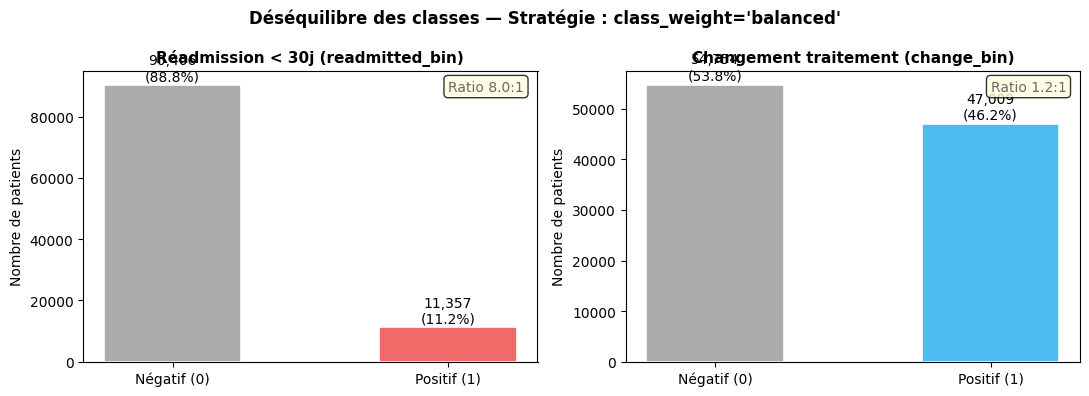

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, target, titre, color_pos in zip(
        axes,
        target_cols,
        ['Réadmission < 30j (readmitted_bin)', 'Changement traitement (change_bin)'],
        [RED, BLUE]):

    counts = df_scaled[target].value_counts().sort_index()
    bars   = ax.bar(['Négatif (0)', 'Positif (1)'],
                    counts.values,
                    color=['#AAAAAA', color_pos],
                    edgecolor='white', linewidth=1.2, width=0.5)
    ax.set_title(titre, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nombre de patients')

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 400,
                f'{val:,}\n({val/n_total*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)

    ratio = counts[0] / counts[1]
    ax.text(0.97, 0.97, f'Ratio {ratio:.1f}:1',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10, color='dimgray',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.suptitle("Déséquilibre des classes — Stratégie : class_weight='balanced'",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

###  Conclusion

L’utilisation de **class_weight='balanced'** permet :

* de corriger le biais vers la classe majoritaire
* d’améliorer la détection des cas rares (patients à risque)
* de garder un modèle robuste sans altérer les données

 C’est une solution efficace, simple et adaptée à ce type de dataset médical.

# 10. VÉRIFICATION FINALE & SAUVEGARDE

  Lignes finales         : 101,763
  Features               : 67
  Cibles                 : ['readmitted_bin', 'change_bin']
  Valeurs manquantes     : 0
  Types restants         : {dtype('float64'): 61, dtype('int64'): 7, dtype('O'): 1}

  Distribution des cibles :
    readmitted_bin → {0: 90406, 1: 11357}
    change_bin → {0: 54754, 1: 47009}


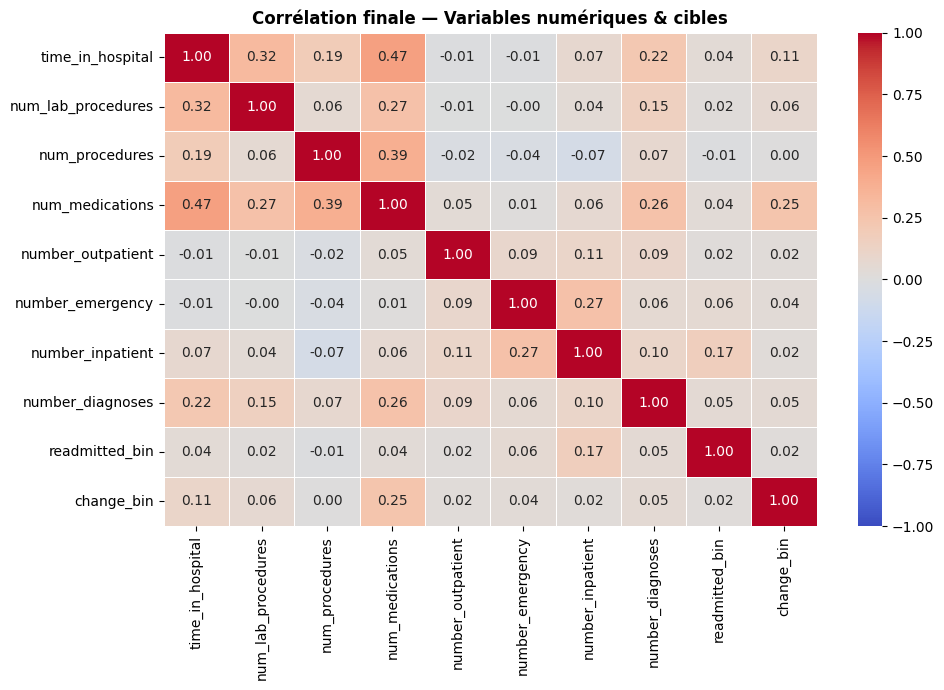


   Dataset sauvegardé : 'diabetic_data_preprocessed.csv'
     Shape : 101,763 lignes × 69 colonnes

    Prochaine étape : Phase 3 — Feature Engineering


In [24]:
X_final = df_scaled.drop(columns=target_cols)
y_final = df_scaled[target_cols]

print(f"  Lignes finales         : {len(df_scaled):,}")
print(f"  Features               : {X_final.shape[1]}")
print(f"  Cibles                 : {target_cols}")
print(f"  Valeurs manquantes     : {df_scaled.isnull().sum().sum()}")
print(f"  Types restants         : {df_scaled.dtypes.value_counts().to_dict()}")
print(f"\n  Distribution des cibles :")
for target in target_cols:
    print(f"    {target} → {df_scaled[target].value_counts().to_dict()}")

#  Heatmap de corrélation finale (top features numériques)
cols_heatmap = cols_to_scale + target_cols
corr = df_scaled[cols_heatmap].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Corrélation finale — Variables numériques & cibles',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

output_path = 'diabetic_data_preprocessed.csv'
df_scaled.to_csv(output_path, index=False)

print(f"\n   Dataset sauvegardé : '{output_path}'")
print(f"     Shape : {df_scaled.shape[0]:,} lignes × {df_scaled.shape[1]} colonnes")
print("\n    Prochaine étape : Phase 3 — Feature Engineering")

